Toy Measurement Control Initialized


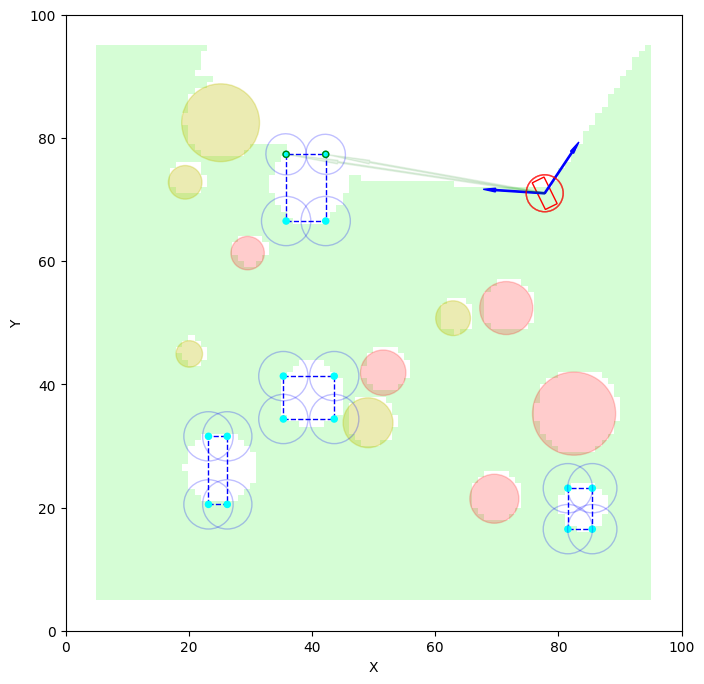

In [6]:
import numpy as np
import pandas as pd
import timeit
import sys
import cProfile
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from copy import deepcopy
# Add measurement mcts python package to path
sys.path.append('../../src/measurement_mcts')
from measurement_mcts.mcts.mcts import mcts_search, get_best_trajectory, MCTSNode, DummyNode
from measurement_mcts.mcts.tree_viz import render_pyvis
from measurement_mcts.environment.measurement_control_env import MeasurementControlEnvironment

env = MeasurementControlEnvironment(init_reset=False)
env.load_state('../../state_configurations', 'evaluation2')
env.draw_state(env.get_state())
starting_state = env.get_state()

# Parameters

In [7]:
learning_iterations = 25
explore_factor = 100
discount_factor = 1.0

# First create the 25 root nodes in a list

In [12]:
roots = []
for action_idx, action in enumerate(env.action_space):
    state, reward, done = env.step(starting_state, action)
    roots.append(MCTSNode(env, state, action_idx, explore_factor=explore_factor, discount_factor=discount_factor,
                          reward=reward, parent=None, done=done))
    

In [33]:
def one_action_mcts(action, learning_iterations=60):
    root = MCTSNode(env, starting_state, action=None, explore_factor=explore_factor, 
                    discount_factor=discount_factor, parent=DummyNode())
    root.maybe_add_child(action)
    action_root = root.children[action]
    
    for i in range(learning_iterations):
        leaf = action_root.select_leaf() # Select with UCB up to the leaf node and do one environment step
        
        # Add the transition to the replay buffer for training (except for the root node)
        # child_priors, value_estimate = eval.inference(leaf.state) # Inference the model to get the probability of each action and the value estimate
        child_priors, value_estimate = np.ones([env.N]) / env.N, 0. # Even probability for each action for testing and no expected reward to go
        
        leaf.expand(child_priors) # Expand the leaf node with the child priors
        leaf.backup(value_estimate) # Backup the value estimate up the tree to the root node
        
    return action_root.Q + action_root.U, root

start_time = timeit.default_timer()
one_action_mcts(0)
print(timeit.default_timer() - start_time)

0.7951851319994603


In [10]:
start_time = timeit.default_timer()
state, reward, done = env.step(starting_state, env.action_space[5])
print(timeit.default_timer() - start_time)

0.017243330001292634


In [44]:
def init_worker(global_env, global_starting_state):
    global env
    global starting_state
    env = global_env
    starting_state = global_starting_state

def parallel_mcts(action_space, env, starting_state, reconstruct_root=False):
    """
    Parallelizes the MCTS using multiprocessing.Pool.
    """
    pool = mp.Pool(processes=len(action_space), initializer=init_worker, initargs=(env, starting_state,))
    
    start_time = timeit.default_timer()
    
    # Distribute the actions to processes
    results = pool.map(one_action_mcts, np.arange(len(action_space)), chunksize=1)
    
    pool.close()
    pool.join()
    
    print(timeit.default_timer() - start_time)
    
    if reconstruct_root:
        # Reconstruct the full root
        root = results[0][1] # Take the full first root
        for i in range(1, len(action_space)):
            root.children[i] = results[i][1].children[i] # Replace the child of the root with the child of the other root
        
        # Find the action with the best value
        best_action = np.argmax(root.child_Q() + root.child_U())
        best_value = root.children[best_action].Q + root.children[best_action].U
    
        return best_action, best_value, root
    
    else:
        # Find the action with the best value
        best_index, (best_value, best_root) = max(enumerate(results), key=lambda x: x[1][0])
        
        
        return best_index, best_value

best_action, best_value, root = parallel_mcts(env.action_space, env, starting_state, reconstruct_root=True)

print(best_action, best_value)

# # Display the tree and state
# render_pyvis(root, env.action_space, show_unsimulated=False)
# env.draw_state(starting_state, plot_explore_grid=True, root_node=root, scaling=4, bias=0.1, max=1., rew=True)

3.035969396998553
0 0.2489233485987929


In [ ]:
# 3.104499062001196
# 13 0.27548789978027344
def parallel_mcts(action_space):
    start_time = timeit.default_timer()
    with ProcessPoolExecutor(max_workers=len(action_space)) as executor:
        results = list(executor.map(one_action_mcts, np.arange(len(action_space))))
    print(timeit.default_timer() - start_time)
    return results

print(parallel_mcts(env.action_space))

1.7017300830002569
[(0.21106023173178395, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f67a4390b50>), (0.2116803200014176, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a203d30>), (0.20489025115966797, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f67a4391090>), (0.20281402526363249, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690d34ad10>), (0.20374530361544702, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f67a4391fc0>), (0.2135302943568076, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a3b4a00>), (0.21098698339154642, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a0df640>), (0.20973176340903005, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a0f7d60>), (0.0828289754929081, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f67a4390790>), (0.19339872175647366, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a067c70>), (0.20630022787278698, <measurement_mcts.mcts.mcts.MCTSNode object at 0x7f690a0dcf40>), (0.21328727660640592, <mea